## Assigment 2:
- Implement SVM method using a machine learning library (such as sklearn or sktorch).
- Train this model on the [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia). Resize the images to $128 \times 128$.
- Evaluate this model using Precision, Recall, and F1 metrics.
- Compare the results of SVM using library to those of implemented SVM.

In [ ]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# ── 1. DATASET PATH ───────────────────────────────────────────────────────────
def find_split_dir(base: Path, split: str) -> Path:
    """Tìm đệ quy thư mục train/val/test dù dataset nằm ở tầng nào."""
    for p in base.rglob(split):
        if p.is_dir():
            children = [c.name for c in p.iterdir() if c.is_dir()]
            if any(c in children for c in ["NORMAL", "PNEUMONIA"]):
                return p
    raise FileNotFoundError(f"Cannot find '{split}' split under {base}")

DATA_ROOT = Path(r"C:\Users\DELL\Downloads\archive (1)")  


train_dir = find_split_dir(DATA_ROOT, "train")
val_dir   = find_split_dir(DATA_ROOT, "val")
test_dir  = find_split_dir(DATA_ROOT, "test")

print(f"✓ Dataset root : {DATA_ROOT.resolve()}")
print(f"  train → {train_dir}")
print(f"  val   → {val_dir}")
print(f"  test  → {test_dir}")

✓ Dataset root : C:\Users\DELL\Downloads\archive (1)
  train → C:\Users\DELL\Downloads\archive (1)\chest_xray\train
  val   → C:\Users\DELL\Downloads\archive (1)\chest_xray\val
  test  → C:\Users\DELL\Downloads\archive (1)\chest_xray\test


In [2]:
# ── 2. HYPER-PARAMETERS 
IMG_SIZE     = 128    # 128×128 grayscale
N_COMPONENTS = 150    # PCA dimensions
C            = 1.0    # SVM regularisation strength (dùng chung cho cả 2 model)

# ── 3. DATA LOADING 
def load_split(split_dir: Path, img_size: int = 128):
    label_map = {"NORMAL": -1, "PNEUMONIA": 1}
    images, labels = [], []
    for cls, lbl in label_map.items():
        cls_dir = split_dir / cls
        if not cls_dir.exists():
            raise FileNotFoundError(cls_dir)
        for fpath in sorted(cls_dir.glob("*.*")):
            if fpath.suffix.lower() not in {".jpeg", ".jpg", ".png"}:
                continue
            try:
                img = (Image.open(fpath)
                            .convert("L")
                            .resize((img_size, img_size), Image.BILINEAR))
                images.append(np.array(img, dtype=np.float32).flatten() / 255.0)
                labels.append(lbl)
            except Exception as e:
                print(f"  skip {fpath.name}: {e}")
        print(f"  {split_dir.name}/{cls}: {sum(l == lbl for l in labels)} imgs")
    return np.stack(images), np.array(labels, dtype=np.int32)

print("\nLoading …")
t0 = time.time()
X_train, y_train = load_split(train_dir, IMG_SIZE)
X_val,   y_val   = load_split(val_dir,   IMG_SIZE)
X_test,  y_test  = load_split(test_dir,  IMG_SIZE)

X_tr = np.concatenate([X_train, X_val])
y_tr = np.concatenate([y_train, y_val])
print(f"Done in {time.time()-t0:.1f}s")
print(f"  Train+Val {X_tr.shape}  Test {X_test.shape}")


Loading …
  train/NORMAL: 1341 imgs
  train/PNEUMONIA: 3875 imgs
  val/NORMAL: 8 imgs
  val/PNEUMONIA: 8 imgs
  test/NORMAL: 234 imgs
  test/PNEUMONIA: 390 imgs
Done in 45.4s
  Train+Val (5232, 16384)  Test (624, 16384)


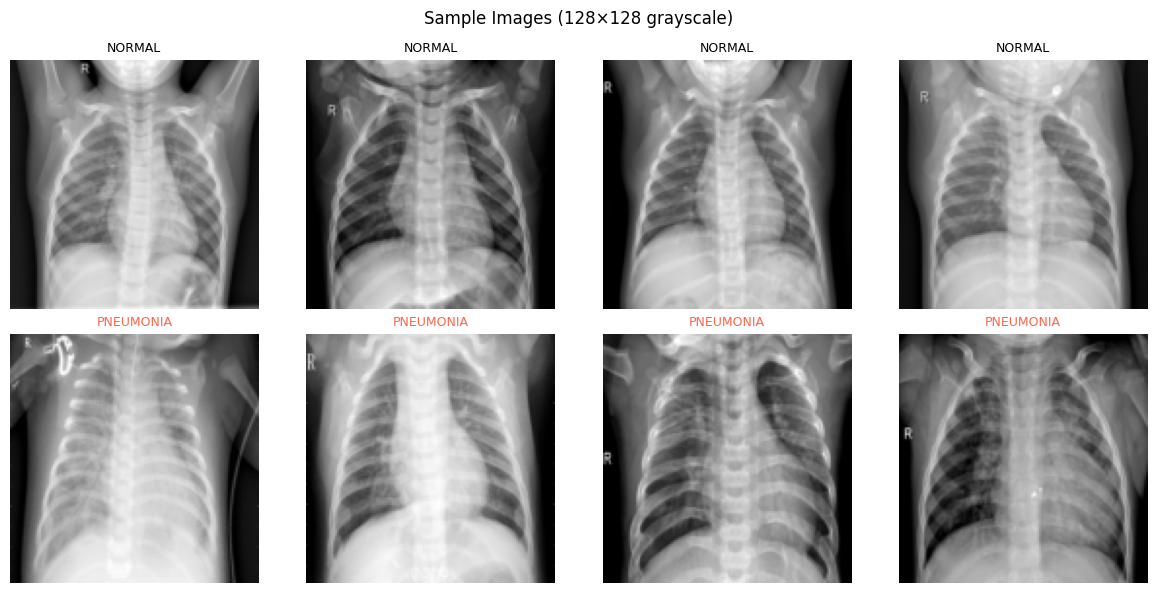


Standardising + PCA …
  150 components → 91.3% variance  |  shape: (5232, 150)


In [3]:
# ── 4. SAMPLE IMAGES 
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes[0], np.where(y_train == -1)[0][:4]):
    ax.imshow(X_train[idx].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    ax.set_title("NORMAL", fontsize=9); ax.axis("off")
for ax, idx in zip(axes[1], np.where(y_train ==  1)[0][:4]):
    ax.imshow(X_train[idx].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    ax.set_title("PNEUMONIA", fontsize=9, color="tomato"); ax.axis("off")
plt.suptitle("Sample Images (128×128 grayscale)"); plt.tight_layout(); plt.show()

# ── 5. PREPROCESSING: StandardScaler + PCA 
print("\nStandardising + PCA …")
scaler = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_test_sc = scaler.transform(X_test)

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_tr_pca   = pca.fit_transform(X_tr_sc)
X_test_pca = pca.transform(X_test_sc)

n_train       = len(X_train)
X_train_pca   = X_tr_pca[:n_train]
X_val_pca     = X_tr_pca[n_train:]

var_exp = np.cumsum(pca.explained_variance_ratio_)[-1] * 100
print(f"  {N_COMPONENTS} components → {var_exp:.1f}% variance  |  shape: {X_tr_pca.shape}")

In [4]:
# ── 6. CUSTOM SVM (NumPy + SGD)
class SoftMarginSVM:
    """Soft-Margin SVM trained with mini-batch SGD (primal / hinge loss)."""
    def __init__(self, C=1.0, lr=0.01, n_epochs=50, batch_size=64, lr_decay=0.95):
        self.C, self.lr0  = C, lr
        self.n_epochs     = n_epochs
        self.batch_size   = batch_size
        self.lr_decay     = lr_decay
        self.w = self.b   = None
        self.train_losses = []
        self.val_losses   = []

    def _loss(self, X, y):
        margin = y * (X @ self.w + self.b)
        return 0.5 * self.w @ self.w + self.C * np.maximum(0.0, 1.0 - margin).mean()

    def _step(self, X_b, y_b, lr):
        B      = len(y_b)
        margin = y_b * (X_b @ self.w + self.b)
        mask   = margin < 1
        dw     = self.w.copy()
        db     = 0.0
        if mask.any():
            dw -= (self.C / B) * (y_b[mask, None] * X_b[mask]).sum(0)
            db  = -(self.C / B) * y_b[mask].sum()
        self.w -= lr * dw
        self.b -= lr * db

    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        N, D   = X.shape
        self.w = np.zeros(D)
        self.b = 0.0
        lr     = self.lr0
        yf     = y.astype(np.float64)
        yvf    = y_val.astype(np.float64) if y_val is not None else None

        for ep in range(1, self.n_epochs + 1):
            perm = np.random.permutation(N)
            for s in range(0, N, self.batch_size):
                idx = perm[s:s + self.batch_size]
                self._step(X[idx], yf[idx], lr)
            lr *= self.lr_decay
            self.train_losses.append(self._loss(X, yf))
            if X_val is not None:
                self.val_losses.append(self._loss(X_val, yvf))
            if verbose and (ep % 10 == 0 or ep == 1):
                vs = f"  val={self.val_losses[-1]:.4f}" if X_val is not None else ""
                print(f"  epoch {ep:>3}/{self.n_epochs}  "
                      f"train={self.train_losses[-1]:.4f}{vs}  lr={lr:.5f}")
        print("Custom SVM training complete ✓")
        return self

    def decision_function(self, X): return X @ self.w + self.b
    def predict(self, X):           return np.sign(self.decision_function(X)).astype(np.int32)

In [7]:
from sklearn.svm import SVC


[Custom SVM] Training …
  epoch   1/50  train=1.6529  val=2.1727  lr=0.00950
  epoch  10/50  train=0.3238  val=0.1776  lr=0.00599
  epoch  20/50  train=0.2319  val=0.5190  lr=0.00358
  epoch  30/50  train=0.1371  val=0.5927  lr=0.00215
  epoch  40/50  train=0.1967  val=0.6163  lr=0.00129
  epoch  50/50  train=0.1052  val=0.5104  lr=0.00077
Custom SVM training complete ✓
  Time: 0.3s


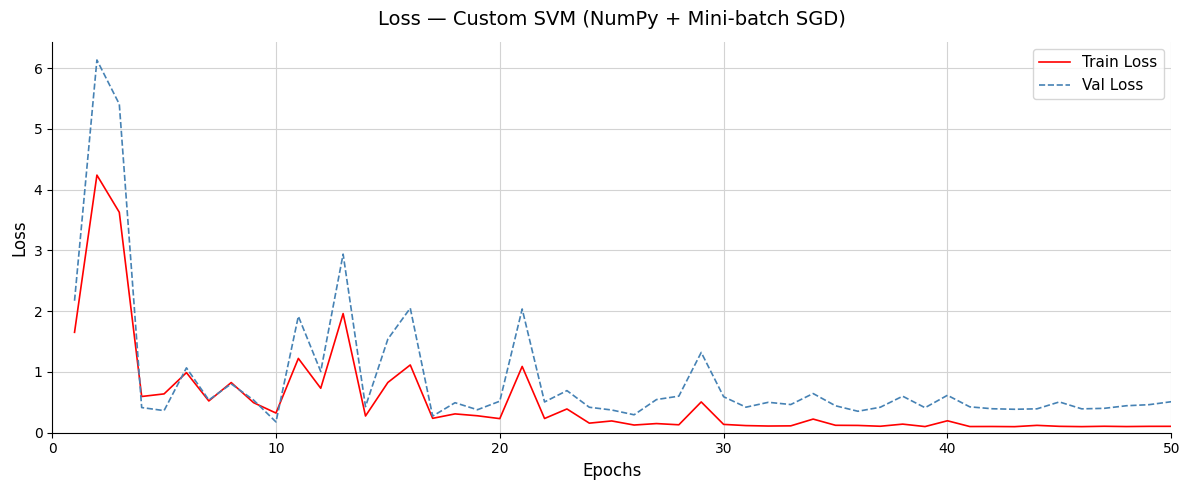


[sklearn SVM] Training …
  Time: 0.5s
sklearn SVM training complete ✓


In [8]:
# ── 7. TRAIN CẢ HAI MODEL

# ── 7-A  Custom SVM (NumPy SGD) 
print("\n[Custom SVM] Training …")
custom_svm = SoftMarginSVM(C=C, lr=0.01, n_epochs=50, batch_size=64, lr_decay=0.95)
t0 = time.time()
custom_svm.fit(X_train_pca, y_train, X_val_pca, y_val)
custom_time = time.time() - t0
print(f"  Time: {custom_time:.1f}s")

# Loss curve (style như ảnh mẫu)
def plot_loss(train_losses, val_losses=None, title="Loss Curve"):
    epochs = np.arange(1, len(train_losses) + 1)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(epochs, train_losses, color="red",       lw=1.2, label="Train Loss")
    if val_losses:
        ax.plot(epochs, val_losses, color="steelblue", lw=1.2,
                ls="--", label="Val Loss")
        ax.legend(fontsize=11)
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("Epochs", fontsize=12)
    ax.set_ylabel("Loss",   fontsize=12)
    ax.set_xlim(0, len(train_losses)); ax.set_ylim(bottom=0)
    ax.grid(True, color="lightgray", lw=0.8); ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout(); plt.show()

plot_loss(custom_svm.train_losses, custom_svm.val_losses,
          title="Loss — Custom SVM (NumPy + Mini-batch SGD)")

# ── 7-B  sklearn SVM ──────────────────────────────────────────────────────────
print("\n[sklearn SVM] Training …")
sklearn_svm = SVC(kernel="rbf", C=C, gamma="scale", random_state=42)
t0 = time.time()
sklearn_svm.fit(X_tr_pca, y_tr)          # dùng toàn bộ train+val
sklearn_time = time.time() - t0
print(f"  Time: {sklearn_time:.1f}s")
print("sklearn SVM training complete ✓")


  CUSTOM SVM (NumPy + SGD)

══════════════════════════════════════════
  Custom SVM — Test
══════════════════════════════════════════
  Accuracy  : 0.7404
  Precision : 0.7103
  Recall    : 0.9872
  F1-Score  : 0.8262
  Confusion Matrix (positive = PNEUMONIA)
              Pred POS   Pred NEG
  True POS :     385          5
  True NEG :     157         77
══════════════════════════════════════════

  SKLEARN SVM (RBF Kernel)

══════════════════════════════════════════
  sklearn SVM — Test
══════════════════════════════════════════
  Accuracy  : 0.7756
  Precision : 0.7404
  Recall    : 0.9872
  F1-Score  : 0.8462
  Confusion Matrix (positive = PNEUMONIA)
              Pred POS   Pred NEG
  True POS :     385          5
  True NEG :     135         99
══════════════════════════════════════════


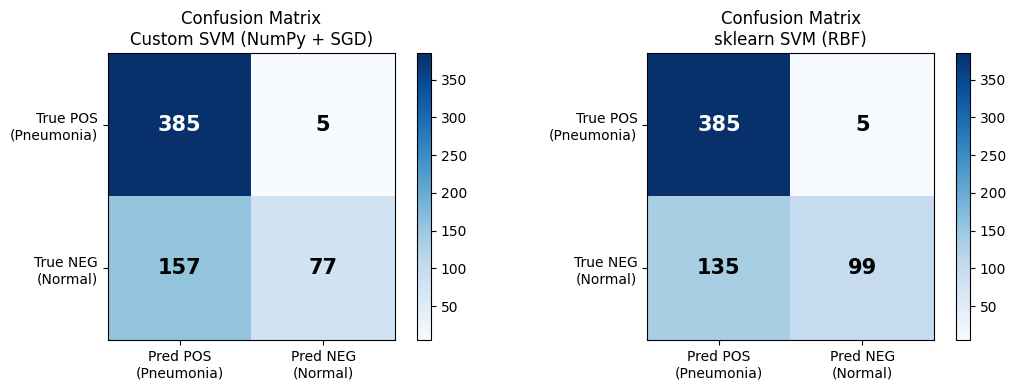

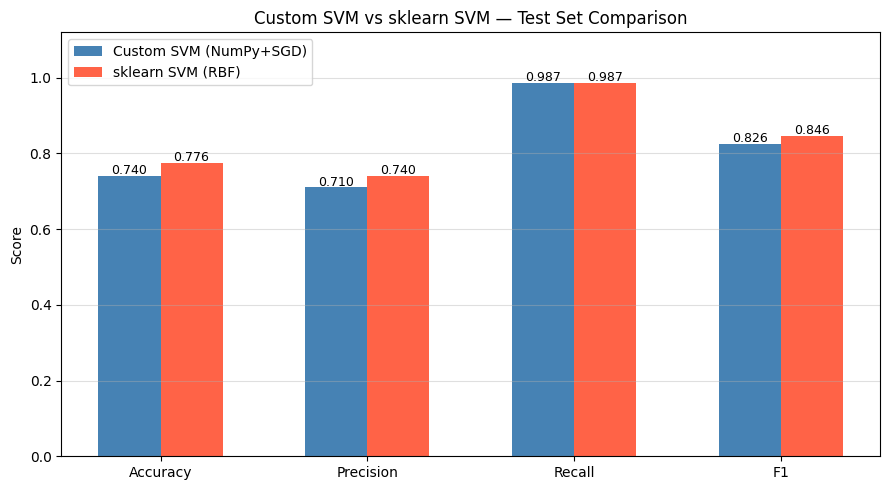

In [9]:

# ── 8. EVALUATION METRICS (giữ nguyên) 
def evaluate(y_true, y_pred, split=""):
    tp = int(((y_pred ==  1) & (y_true ==  1)).sum())
    fp = int(((y_pred ==  1) & (y_true == -1)).sum())
    fn = int(((y_pred == -1) & (y_true ==  1)).sum())
    tn = int(((y_pred == -1) & (y_true == -1)).sum())
    acc  = (tp + tn) / len(y_true)
    prec = tp / (tp + fp) if tp + fp > 0 else 0.0
    rec  = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0.0
    print(f"\n{'═'*42}")
    print(f"  {split}")
    print(f"{'═'*42}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  Confusion Matrix (positive = PNEUMONIA)")
    print(f"              Pred POS   Pred NEG")
    print(f"  True POS :   {tp:5d}      {fn:5d}")
    print(f"  True NEG :   {fp:5d}      {tn:5d}")
    print(f"{'═'*42}")
    return dict(acc=acc, prec=prec, rec=rec, f1=f1, tp=tp, fp=fp, fn=fn, tn=tn)

print("\n" + "="*50)
print("  CUSTOM SVM (NumPy + SGD)")
print("="*50)
custom_m = evaluate(y_test, custom_svm.predict(X_test_pca), "Custom SVM — Test")

print("\n" + "="*50)
print("  SKLEARN SVM (RBF Kernel)")
print("="*50)
sklearn_m = evaluate(y_test, sklearn_svm.predict(X_test_pca), "sklearn SVM — Test")

# ── 9. PLOTS 

# 9-A  Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, m, title in zip(axes,
                         [custom_m, sklearn_m],
                         ["Custom SVM (NumPy + SGD)", "sklearn SVM (RBF)"]):
    cm = np.array([[m["tp"], m["fn"]], [m["fp"], m["tn"]]])
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=15,
                    fontweight="bold",
                    color="white" if cm[i,j] > cm.max()*0.6 else "black")
    ax.set_xticks([0,1]); ax.set_xticklabels(["Pred POS\n(Pneumonia)", "Pred NEG\n(Normal)"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["True POS\n(Pneumonia)", "True NEG\n(Normal)"])
    ax.set_title(f"Confusion Matrix\n{title}")
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# 9-B  So sánh metrics 2 model
metrics = ["Accuracy", "Precision", "Recall", "F1"]
keys    = ["acc",      "prec",      "rec",    "f1"]
custom_v  = [custom_m[k]  for k in keys]
sklearn_v = [sklearn_m[k] for k in keys]

x = np.arange(len(metrics)); bw = 0.3
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - bw/2, custom_v,  bw, label="Custom SVM (NumPy+SGD)", color="steelblue")
b2 = ax.bar(x + bw/2, sklearn_v, bw, label="sklearn SVM (RBF)",      color="tomato")
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + .005,
                f"{bar.get_height():.3f}",
                ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12); ax.set_ylabel("Score")
ax.set_title("Custom SVM vs sklearn SVM — Test Set Comparison")
ax.legend(); ax.grid(axis="y", alpha=.4)
plt.tight_layout(); plt.show()

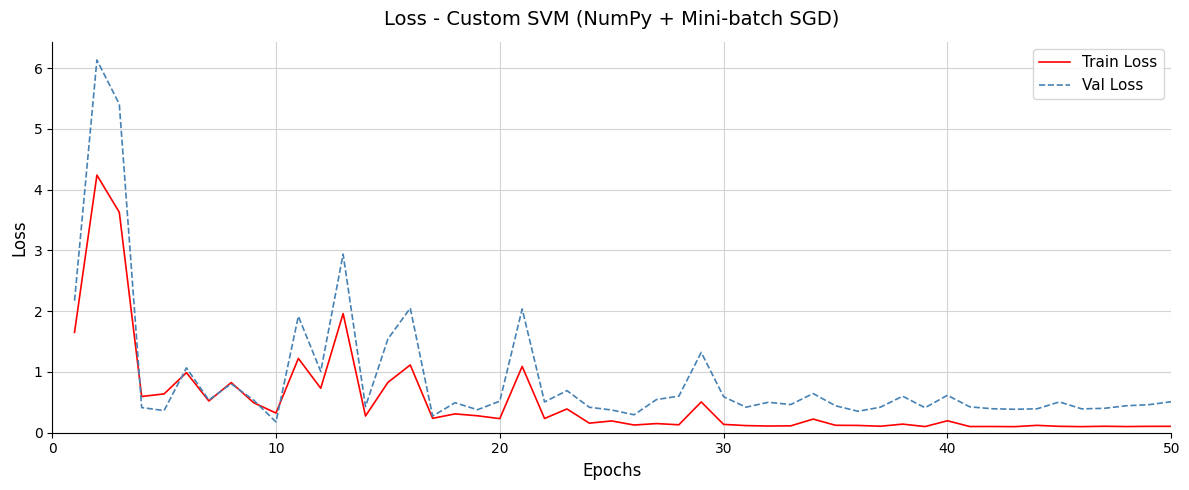


[sklearn SVM] Không có loss curve.
  sklearn SVC dùng thuật toán tối ưu nội bộ (SMO-based),


In [11]:
def plot_loss(train_losses, val_losses=None, title="Loss - PCA Features + Mini-batch SGD"):
    epochs = np.arange(1, len(train_losses) + 1)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(epochs, train_losses,
            color="red", linewidth=1.2, label="Train Loss")
    if val_losses and len(val_losses) == len(train_losses):
        ax.plot(epochs, val_losses,
                color="steelblue", linewidth=1.2,
                linestyle="--", label="Val Loss")
    ax.legend(fontsize=11)
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("Epochs", fontsize=12)
    ax.set_ylabel("Loss",   fontsize=12)
    ax.set_xlim(0, len(train_losses))
    ax.set_ylim(bottom=0)
    ax.grid(True, color="lightgray", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

# ── Chỉ Custom SVM có loss curve, sklearn SVM không có ───────────────────────
plot_loss(custom_svm.train_losses,
          custom_svm.val_losses,
          title="Loss - Custom SVM (NumPy + Mini-batch SGD)")

# sklearn SVM không có loss curve → hiển thị note thay thế
print("\n[sklearn SVM] Không có loss curve.")
print("  sklearn SVC dùng thuật toán tối ưu nội bộ (SMO-based),")